In [1]:
# If running in a fresh environment, run this cell:
!pip uninstall -y tensorflow keras pennylane imbalanced-learn
!pip install tensorflow==2.15.0 keras==2.15.0 pennylane==0.39 imbalanced-learn

Found existing installation: tensorflow 2.17.1
Uninstalling tensorflow-2.17.1:
  Successfully uninstalled tensorflow-2.17.1
Found existing installation: keras 3.5.0
Uninstalling keras-3.5.0:
  Successfully uninstalled keras-3.5.0
Found existing installation: imbalanced-learn 0.12.4
Uninstalling imbalanced-learn-0.12.4:
  Successfully uninstalled imbalanced-learn-0.12.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 69.5 MB/

All classes copied into local 'dataset' folder!
Train/Val/Test split completed!
Found 3892 images belonging to 6 classes.
Found 831 images belonging to 6 classes.
Found 840 images belonging to 6 classes.


/usr/local/lib/python3.10/dist-packages/pennylane/workflow/qnode.py:148: UserWarning: Received gradient_kwarg batching, which is not included in the list of standard qnode gradient kwargs.
  warnings.warn(


94765736/94765736 [==============================] - 0s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                         

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


122/122 [==============================] - 236s 2s/step - loss: 1.4832 - accuracy: 0.4414 - val_loss: 1.5506 - val_accuracy: 0.2250 - lr: 1.0000e-04
Epoch 2/100
122/122 [==============================] - ETA: 0s - loss: 1.3250 - accuracy: 0.5457
Epoch 2: val_loss improved from 1.55057 to 1.49392, saving model to best_model.h5
122/122 [==============================] - 211s 2s/step - loss: 1.3250 - accuracy: 0.5457 - val_loss: 1.4939 - val_accuracy: 0.4031 - lr: 1.0000e-04
Epoch 3/100
122/122 [==============================] - ETA: 0s - loss: 1.2489 - accuracy: 0.5727
Epoch 3: val_loss did not improve from 1.49392
122/122 [==============================] - 209s 2s/step - loss: 1.2489 - accuracy: 0.5727 - val_loss: 1.8450 - val_accuracy: 0.2359 - lr: 1.0000e-04
Epoch 4/100
122/122 [==============================] - ETA: 0s - loss: 1.1933 - accuracy: 0.5994
Epoch 4: val_loss did not improve from 1.49392
122/122 [==============================] - 210s 2s/step - loss: 1.1933 - accuracy: 0.5

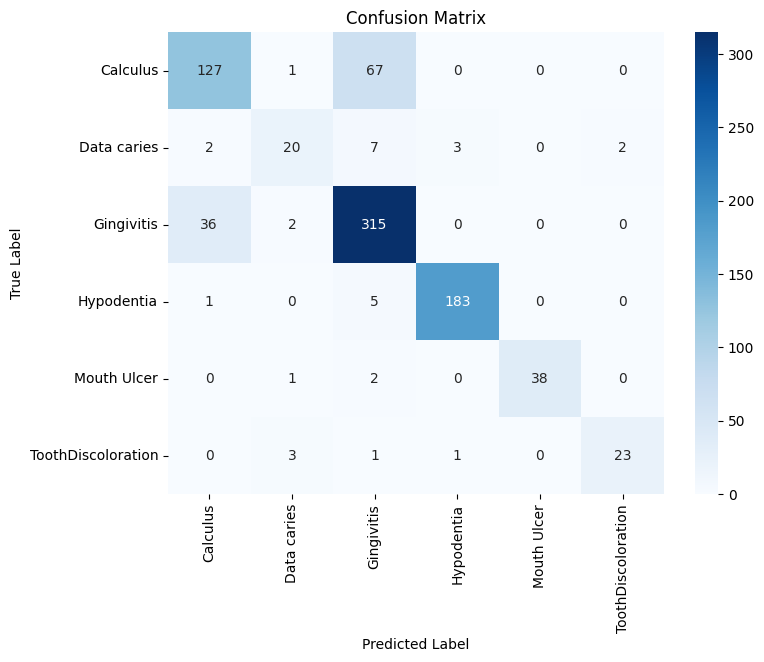

Classification Report:
                    precision    recall  f1-score   support

          Calculus       0.77      0.65      0.70       195
       Data caries       0.74      0.59      0.66        34
        Gingivitis       0.79      0.89      0.84       353
        Hypodentia       0.98      0.97      0.97       189
       Mouth Ulcer       1.00      0.93      0.96        41
ToothDiscoloration       0.92      0.82      0.87        28

          accuracy                           0.84       840
         macro avg       0.87      0.81      0.83       840
      weighted avg       0.84      0.84      0.84       840



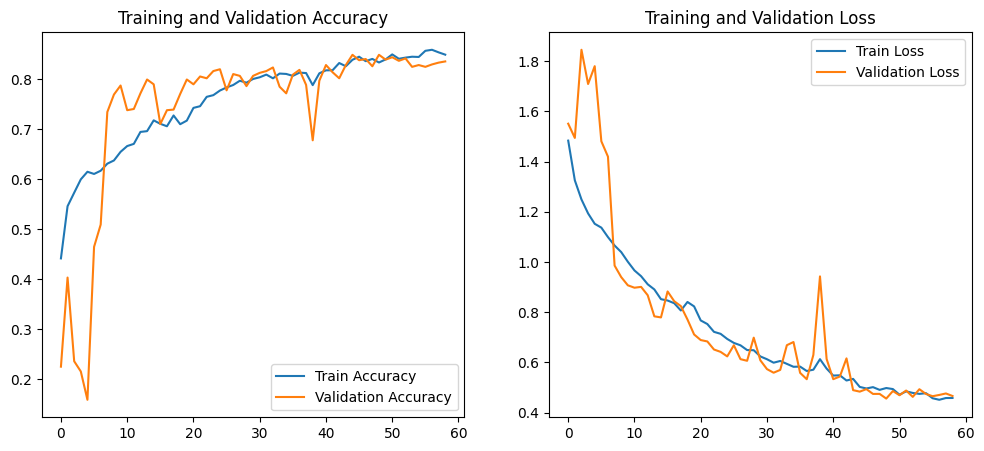

In [2]:
#!/usr/bin/env python
# %% [code]
# Uninstall and install specific versions


# %% [code]
import os
import shutil
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Quantum imports
import pennylane as qml

# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# %% [code]
# Define the base dataset path and class names
base_dataset_path = "/kaggle/input/oral-diseases"  # Adjust if needed
class_names = [
    "Calculus",
    "Data caries",
    "Gingivitis",
    "Mouth Ulcer",
    "ToothDiscoloration",
    "Hypodentia"
]
num_classes = len(class_names)

# Mapping from class name to folder path (adjust these as per your dataset)
cls_folder_map = {
    "Calculus": "Calculus/Calculus",
    "Data caries": "Data caries/Data caries/caries orignal data set/done",
    "Gingivitis": "Gingivitis/Gingivitis",
    "Mouth Ulcer": "Mouth Ulcer/Mouth Ulcer/ulcer original dataset/ulcer original dataset",
    "ToothDiscoloration": "Tooth Discoloration/Tooth Discoloration /tooth discoloration original dataset/tooth discoloration original dataset",
    "Hypodentia": "hypodontia/hypodontia"
}

# Copy all class folders into a local dataset directory
working_dir = "/kaggle/working/"
dataset_dir = os.path.join(working_dir, "dataset")
os.makedirs(dataset_dir, exist_ok=True)

for cls in class_names:
    src = os.path.join(base_dataset_path, cls_folder_map[cls])
    dst = os.path.join(dataset_dir, cls)
    shutil.copytree(src, dst, dirs_exist_ok=True)
print("All classes copied into local 'dataset' folder!")

# %% [code]
# Create directories for train, validation, and test splits
train_dir = os.path.join(working_dir, "train")
val_dir   = os.path.join(working_dir, "val")
test_dir  = os.path.join(working_dir, "test")
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)
    for cls in class_names:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

# Split each class into 70% train, 15% val, 15% test
for cls in class_names:
    class_path = os.path.join(dataset_dir, cls)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)
    n_total = len(images)
    n_train = int(0.7 * n_total)
    n_val   = int(0.15 * n_total)
    train_files = images[:n_train]
    val_files   = images[n_train:n_train + n_val]
    test_files  = images[n_train + n_val:]
    
    for f in train_files:
        shutil.move(os.path.join(class_path, f), os.path.join(train_dir, cls, f))
    for f in val_files:
        shutil.move(os.path.join(class_path, f), os.path.join(val_dir, cls, f))
    for f in test_files:
        shutil.move(os.path.join(class_path, f), os.path.join(test_dir, cls, f))
print("Train/Val/Test split completed!")

# %% [code]
# Define image size and batch size for training
image_size = (224, 224)
batch_size = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2
)
# Only rescaling for validation and testing
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical"
)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical"
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# %% [code]
# Define a function to build the hybrid quantum-classical model.
def build_hybrid_model(num_quantum_layers=6, dropout_rate=0.3, fine_tune_backbone=False):
    """
    Build a hybrid quantum-classical model.
    
    Parameters:
      num_quantum_layers (int): Number of entanglement repetitions in the quantum circuit.
      dropout_rate (float): Dropout rate applied after the quantum layer.
      fine_tune_backbone (bool): Whether to unfreeze the last few layers of ResNet50 for fine-tuning.
    Returns:
      model: The compiled hybrid model.
    """
    num_qubits = 6  # fixed to match output of classical dense layer

    # Define the quantum circuit.
    dev = qml.device("default.qubit", wires=num_qubits)
    
    @qml.qnode(dev, interface='tf', batching=True)
    def quantum_circuit(inputs, weights):
        # Apply Hadamard gates to each qubit
        for i in range(num_qubits):
            qml.Hadamard(wires=i)
        # Data embedding using RY gates
        for i in range(num_qubits):
            qml.RY(inputs[:, i], wires=i)
        # Quantum layers (entanglement layers)
        for layer in range(num_quantum_layers):
            for i in range(num_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
            for i in range(num_qubits - 1):
                qml.CZ(wires=[i, i + 1])
            qml.CZ(wires=[num_qubits - 1, 0])
            for i in range(num_qubits):
                qml.RZ(weights[layer, i, 1], wires=i)
        # Final rotation and measurement preparation
        for i in range(num_qubits):
            qml.RX(weights[num_quantum_layers, i, 0], wires=i)
            qml.Hadamard(wires=i)
        return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]
    
    # Define weight shapes; note: one additional row for final rotation.
    weight_shapes = {"weights": (num_quantum_layers + 1, num_qubits, 2)}
    quantum_layer = qml.qnn.KerasLayer(
        quantum_circuit, 
        weight_shapes, 
        output_dim=num_qubits,
        name="quantum_layer"
    )
    
    # --- Classical Backbone: Pretrained ResNet50 ---
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    # Add a dense layer with tanh to match number of qubits
    x = Dense(num_qubits, activation='tanh', name="pre_quantum_dense")(x)
    
    # Optionally add BatchNormalization
    x = BatchNormalization()(x)
    
    # Insert the quantum layer
    x = quantum_layer(x)
    
    # Add dropout for regularization
    x = Dropout(dropout_rate)(x)
    
    # Final classification layer
    outputs = Dense(num_classes, activation="softmax")(x)
    
    model = models.Model(inputs=base_model.input, outputs=outputs)
    
    # Optionally fine-tune the backbone: unfreeze last 10 layers (or adjust as needed)
    if fine_tune_backbone:
        for layer in base_model.layers[-10:]:
            layer.trainable = True
    else:
        # Freeze backbone layers
        for layer in base_model.layers:
            layer.trainable = False

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    
    return model

# %% [code]
# Build the model with default parameters for training.
model = build_hybrid_model(num_quantum_layers=6, dropout_rate=0.3, fine_tune_backbone=True)
model.summary()

# Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

# %% [code]
# Train the model
initial_epochs = 100
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=initial_epochs,
    callbacks=callbacks,
    verbose=1
)

# %% [code]
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
model.save("final_best_model.h5")
print("Model saved successfully!")

# %% [code]
# Generate confusion matrix and classification report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names_list = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names_list, yticklabels=class_names_list)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names_list))

# %% [code]
# Plot training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
Random test images selected for Grad-CAM visualization:
['/kaggle/working/test/Hypodentia/(37).JPG', '/kaggle/working/test/Hypodentia/(819).jpg', '/kaggle/working/test/Calculus/(551).jpg', '/kaggle/working/test/Calculus/(241).jpg', '/kaggle/working/test/Mouth Ulcer/119.jpg', '/kaggle/working/test/Mouth Ulcer/139.jpg', '/kaggle/working/test/Gingivitis/(2141).jpg', '/kaggle/working/test/Gingivitis/(2257).jpg', '/kaggle/working/test/Data caries/149.jpg', '/kaggle/working/test/Data caries/177.jpg', '/kaggle/working/test/ToothDiscoloration/100.jpg', '/kaggle/working/test/ToothDiscoloration/96.jpg']
1/1 [==============================] - 1s 953ms/step


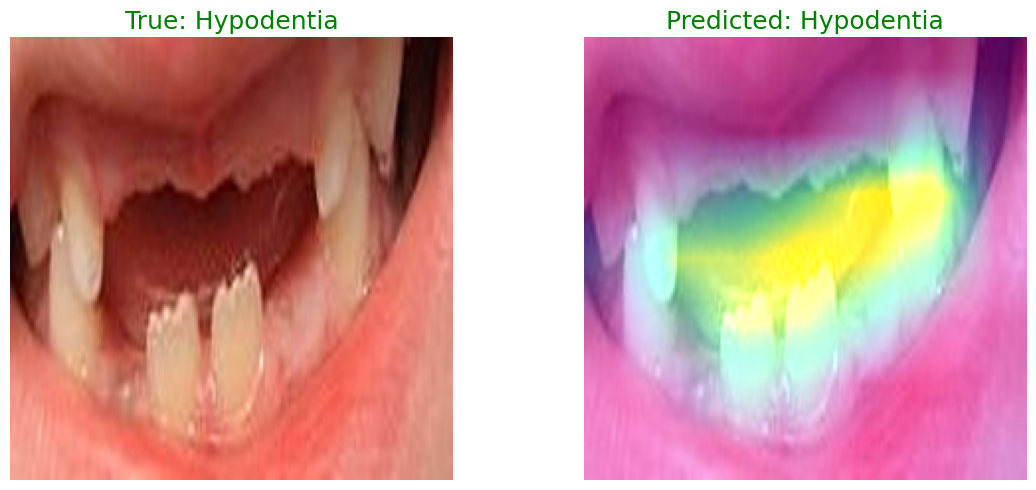

1/1 [==============================] - 0s 450ms/step


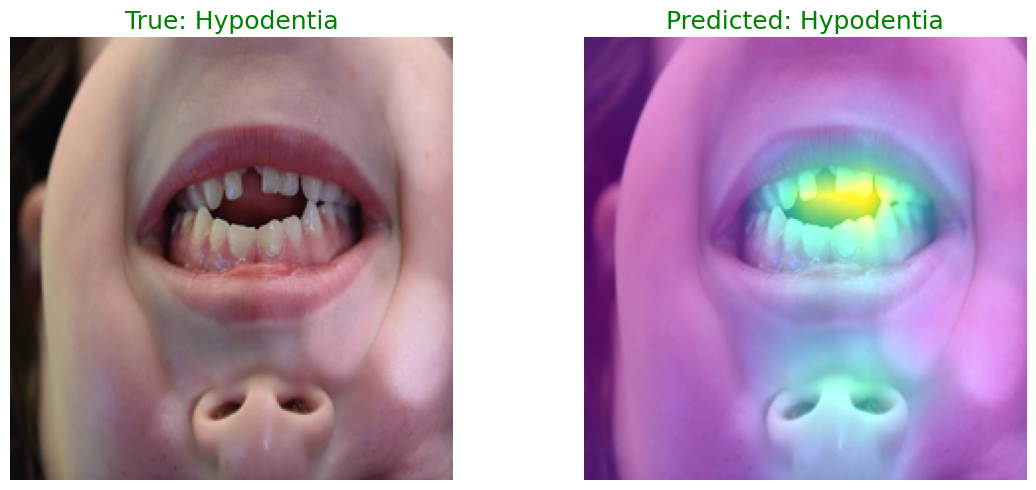

1/1 [==============================] - 0s 437ms/step


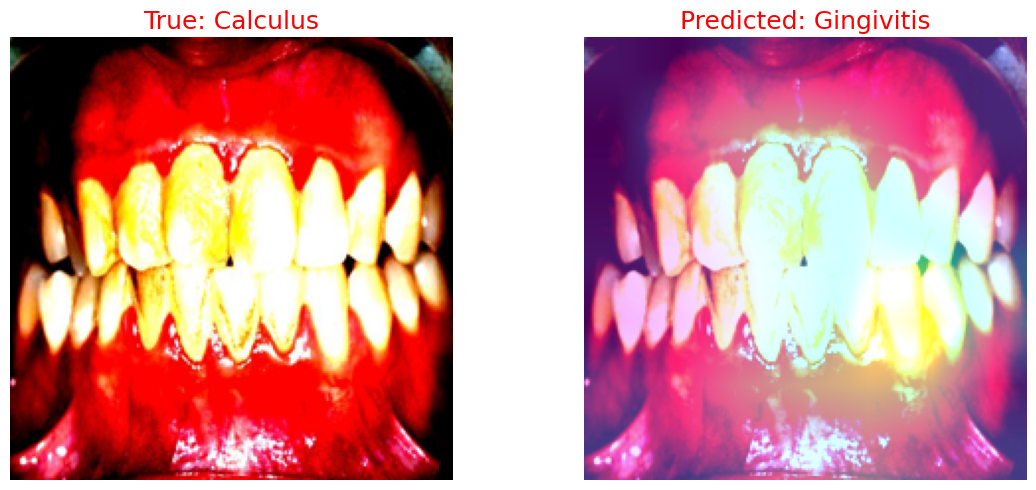

1/1 [==============================] - 0s 438ms/step


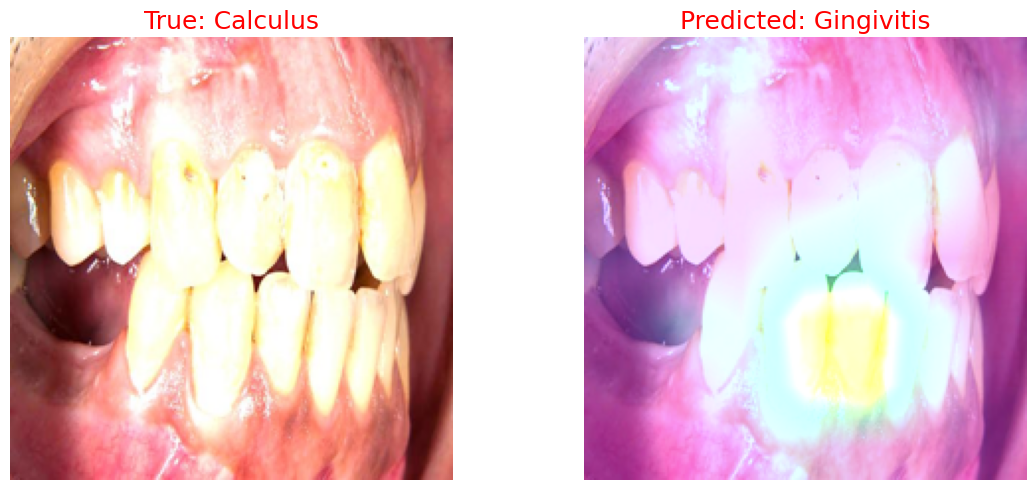

1/1 [==============================] - 0s 448ms/step


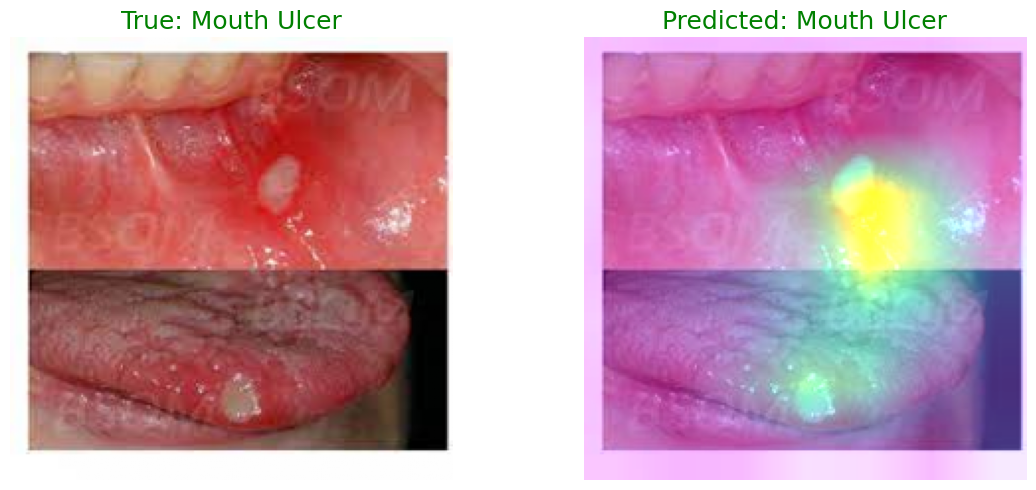

1/1 [==============================] - 0s 448ms/step


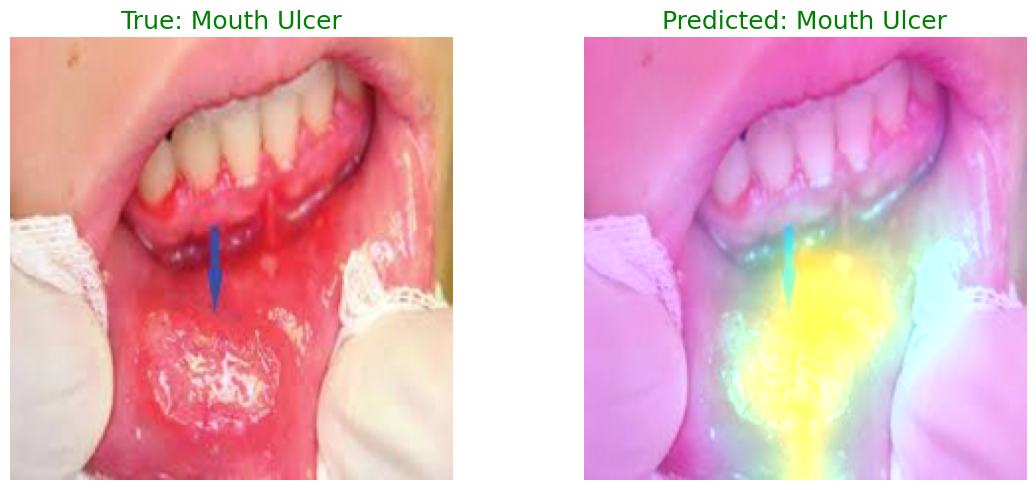

1/1 [==============================] - 0s 447ms/step


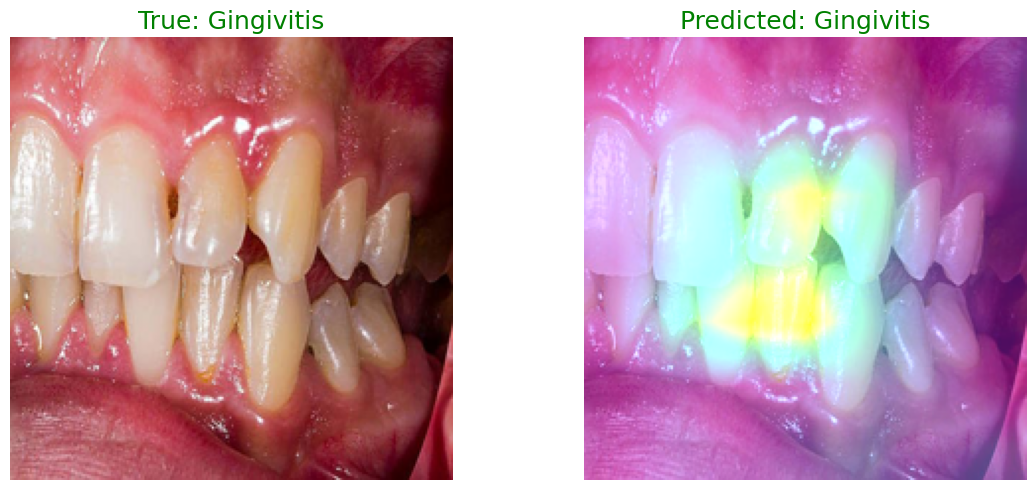

1/1 [==============================] - 0s 451ms/step


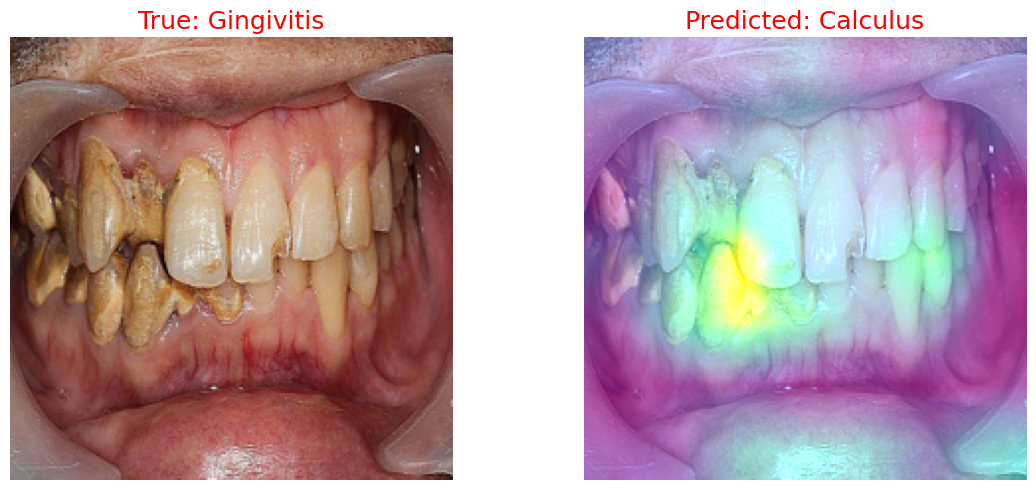

1/1 [==============================] - 0s 453ms/step


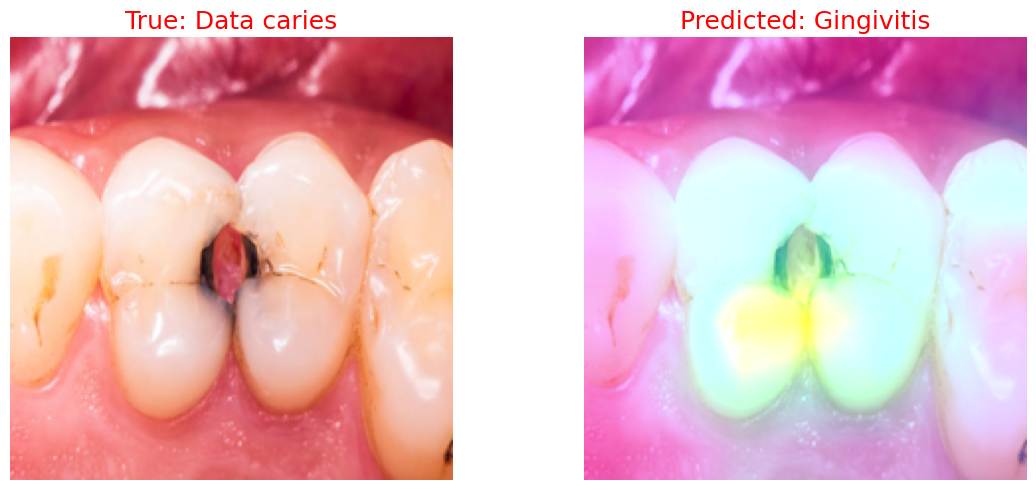

1/1 [==============================] - 0s 446ms/step


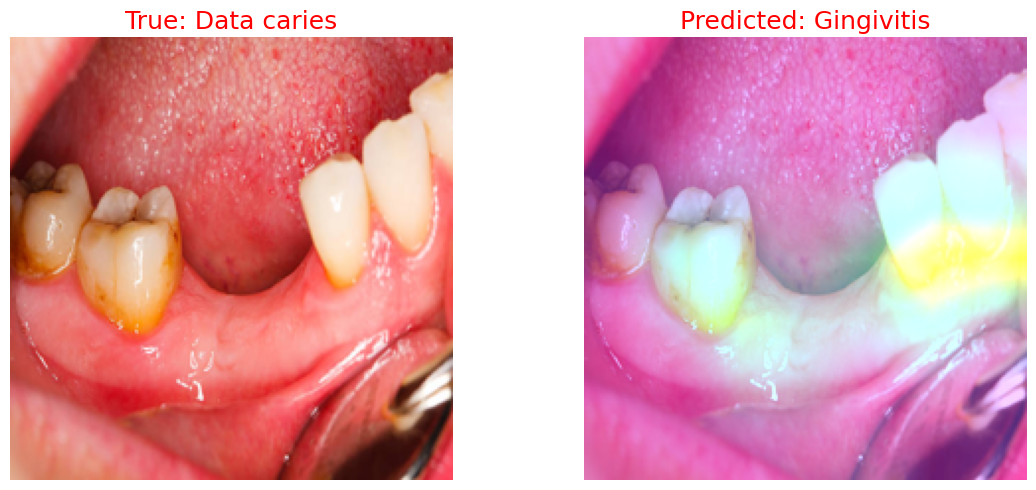

1/1 [==============================] - 0s 458ms/step


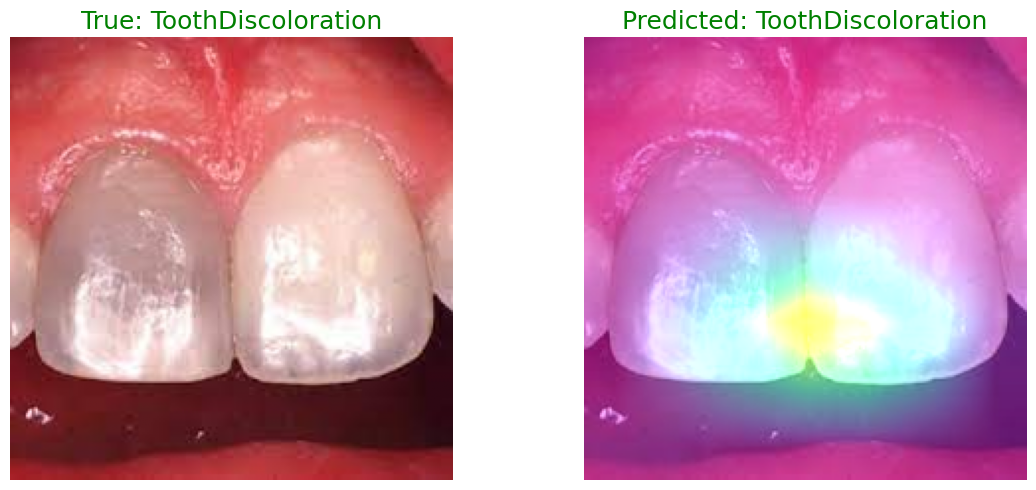

1/1 [==============================] - 0s 452ms/step


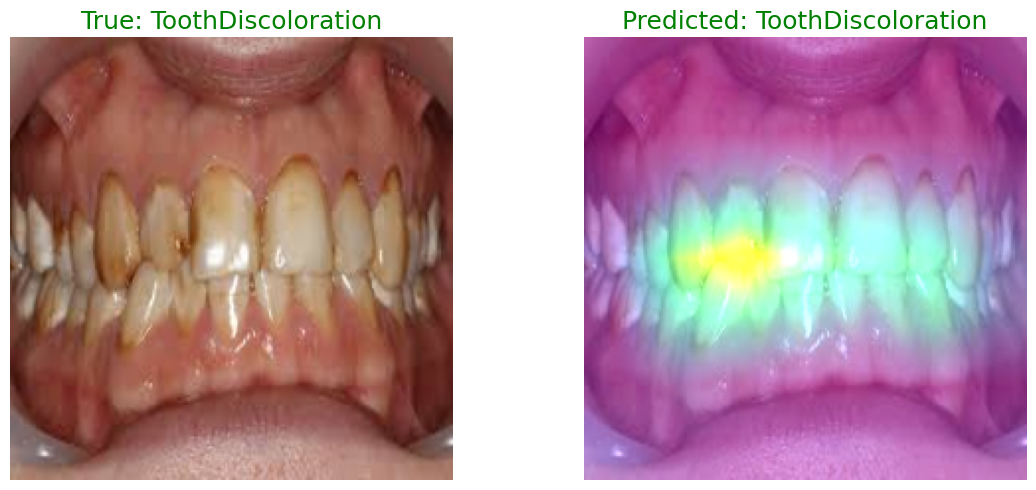

27/27 [==============================] - 4s 102ms/step


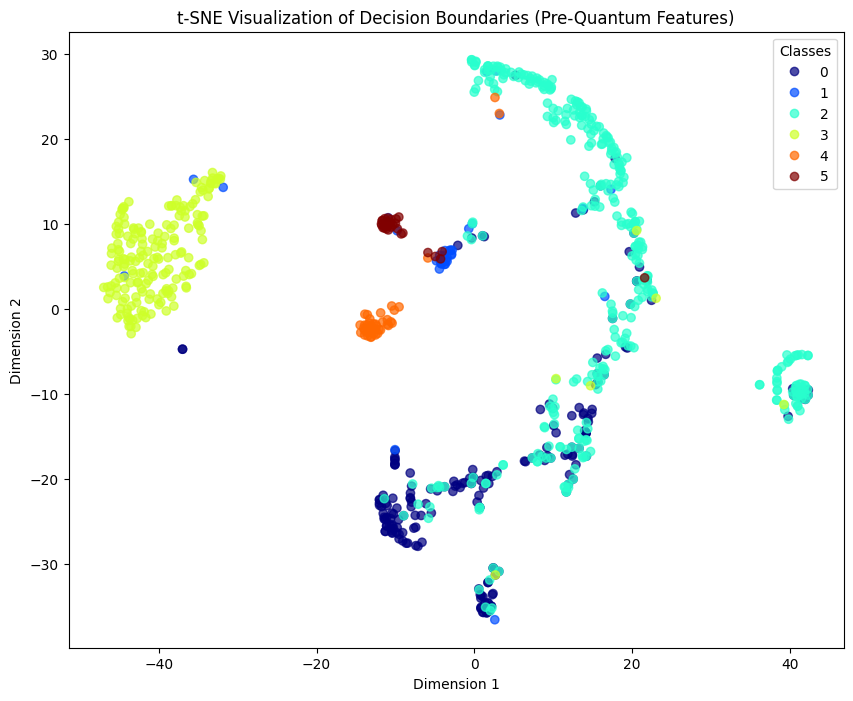

In [3]:
# %% [code]
# Model Interpretability: Grad-CAM for Feature Importance Maps
!pip install tf-explain
from PIL import Image
from tf_explain.core.grad_cam import GradCAM

def visualize_grad_cam(image_paths, model, class_names, target_layer_name="conv5_block3_out"):
    """
    Generates and displays Grad-CAM visualizations for a list of images.
    """
    for image_path in image_paths:
        image_orig = Image.open(image_path).convert("RGB")
        image_resized = image_orig.resize((image_size[0], image_size[1]))
        image_array = np.array(image_resized)
        input_tensor = image_array.astype(np.float32) / 255.0
        input_tensor = np.expand_dims(input_tensor, axis=0)
        
        preds = model.predict(input_tensor)
        predicted_class_index = np.argmax(preds[0])
        predicted_class = class_names[predicted_class_index]
        true_class = os.path.basename(os.path.dirname(image_path))
        
        explainer = GradCAM()
        data = (input_tensor, None)
        with tf.device('/CPU:0'):
            cam_grid = explainer.explain(data, model, class_index=predicted_class_index, layer_name=target_layer_name)
        
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(image_array / 255.0)
        plt.title(f"True: {true_class}", fontsize=18,
                  color='green' if true_class == predicted_class else 'red')
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(cam_grid)
        plt.title(f"Predicted: {predicted_class}", fontsize=18,
                  color='green' if true_class == predicted_class else 'red')
        plt.axis("off")
        plt.tight_layout()
        plt.show()

def get_random_images_from_folders(base_folder, num_images_per_folder=2):
    image_paths = []
    subfolders = [f.path for f in os.scandir(base_folder) if f.is_dir()]
    for subfolder in subfolders:
        images = [os.path.join(subfolder, f) for f in os.listdir(subfolder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if len(images) > 0:
            image_paths.extend(np.random.choice(images, min(num_images_per_folder, len(images)), replace=False))
    return image_paths

base_test_folder = test_dir
random_test_images = get_random_images_from_folders(base_test_folder, num_images_per_folder=2)
print("Random test images selected for Grad-CAM visualization:")
print(random_test_images)
visualize_grad_cam(random_test_images, model, class_names_list, target_layer_name="conv5_block3_out")

# %% [code]
# Additional Model Interpretability: Analyze Decision Boundaries using t-SNE.
from sklearn.manifold import TSNE

# Extract features from the pre-quantum dense layer ("pre_quantum_dense")
feature_extractor = models.Model(inputs=model.input, outputs=model.get_layer("pre_quantum_dense").output)
features = feature_extractor.predict(test_generator)
# Use t-SNE to reduce features to 2D
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=y_true, cmap='jet', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("t-SNE Visualization of Decision Boundaries (Pre-Quantum Features)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

# %% [code]

In [4]:
# =======================
# ABALATION STUDIES CODE
# =======================

# Define a function to build the hybrid quantum-classical model with variable quantum layers
def build_hybrid_model_ablation(num_quantum_layers):
    # Create a quantum device with the fixed number of qubits
    num_qubits = 6
    dev = qml.device("default.qubit", wires=num_qubits)
    
    # Define a quantum circuit that uses a variable number of layers
    @qml.qnode(dev, interface='tf', batching=True)
    def quantum_circuit(inputs, weights):
        # Apply Hadamard gates to each qubit
        for i in range(num_qubits):
            qml.Hadamard(wires=i)
        # Embed classical data using RY gates
        for i in range(num_qubits):
            qml.RY(inputs[:, i], wires=i)
        # Use the specified number of quantum layers
        for layer in range(num_quantum_layers):
            # Parameterized RY rotations
            for i in range(num_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
            # Entanglement with CZ gates
            for i in range(num_qubits - 1):
                qml.CZ(wires=[i, i + 1])
            qml.CZ(wires=[num_qubits - 1, 0])
            # Parameterized RZ rotations
            for i in range(num_qubits):
                qml.RZ(weights[layer, i, 1], wires=i)
        # Final rotation and measurement preparation
        for i in range(num_qubits):
            qml.RX(weights[num_quantum_layers, i, 0], wires=i)
            qml.Hadamard(wires=i)
        # Return expectation values for each qubit
        return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]
    
    # Define weight shapes (one extra row for the final rotation)
    weight_shapes = {"weights": (num_quantum_layers + 1, num_qubits, 2)}
    quantum_layer = qml.qnn.KerasLayer(
        quantum_circuit,
        weight_shapes,
        output_dim=num_qubits,
        name="quantum_layer"
    )
    
    # --- Classical Backbone: Pretrained ResNet50 ---
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    # Dense layer to match number of qubits (using tanh activation)
    x = Dense(num_qubits, activation='tanh', name="pre_quantum_dense")(x)
    
    # Insert the quantum layer
    x = quantum_layer(x)
    # Final classification layer remains unchanged
    outputs = Dense(num_classes, activation="softmax")(x)
    
    # Build and compile the model
    model_ablation = models.Model(inputs=base_model.input, outputs=outputs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model_ablation.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    return model_ablation

# --- Ablation Study 1: Varying Quantum Circuit Depth ---
ablation_results = {}
for q_layers in [3, 6, 9]:
    print(f"\nTraining hybrid model with {q_layers} quantum layers...")
    model_ablation = build_hybrid_model_ablation(num_quantum_layers=q_layers)
    
    # Train for a few epochs for ablation purposes (adjust epochs as needed)
    history_ablation = model_ablation.fit(
         train_generator,
         validation_data=val_generator,
         epochs=10,  # Fewer epochs for ablation study
         callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)],
         verbose=1
    )
    test_loss, test_acc = model_ablation.evaluate(test_generator, verbose=0)
    ablation_results[q_layers] = test_acc
    print(f"Quantum Layers: {q_layers} -> Test Accuracy: {test_acc:.4f}")

print("\nAblation Study Results (Quantum Circuit Depth vs. Test Accuracy):")
for layers_count, acc_val in ablation_results.items():
    print(f"{layers_count} layers: {acc_val:.4f}")

# --- Ablation Study 2: Pure Classical Model (No Quantum Layer) ---
def build_classical_model():
    # Build a classical model with the same ResNet50 backbone and similar post-processing
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    # Optionally add a Dense layer for representation (here using 64 units)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(num_classes, activation="softmax")(x)
    
    classical_model = models.Model(inputs=base_model.input, outputs=outputs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    classical_model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    return classical_model

print("\nAblation Study: Pure Classical Model (no quantum layer)")
model_classical = build_classical_model()
history_classical = model_classical.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,  # Fewer epochs for ablation study
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)],
    verbose=1
)
test_loss_classical, test_acc_classical = model_classical.evaluate(test_generator, verbose=0)
print(f"Pure Classical Model Test Accuracy: {test_acc_classical:.4f}")


Training hybrid model with 3 quantum layers...


/usr/local/lib/python3.10/dist-packages/pennylane/workflow/qnode.py:148: UserWarning: Received gradient_kwarg batching, which is not included in the list of standard qnode gradient kwargs.
  warnings.warn(


Epoch 1/10
122/122 [==============================] - 186s 1s/step - loss: 1.4348 - accuracy: 0.6303 - val_loss: 1.6880 - val_accuracy: 0.4212
Epoch 2/10
122/122 [==============================] - 166s 1s/step - loss: 1.3292 - accuracy: 0.6886 - val_loss: 1.7959 - val_accuracy: 0.2202
Epoch 3/10
122/122 [==============================] - 166s 1s/step - loss: 1.2746 - accuracy: 0.6984 - val_loss: 1.8156 - val_accuracy: 0.2443
Epoch 4/10
122/122 [==============================] - 166s 1s/step - loss: 1.2168 - accuracy: 0.7099 - val_loss: 2.0103 - val_accuracy: 0.1721
Quantum Layers: 3 -> Test Accuracy: 0.4179

Training hybrid model with 6 quantum layers...
Epoch 1/10
122/122 [==============================] - 230s 2s/step - loss: 1.5791 - accuracy: 0.4635 - val_loss: 1.6208 - val_accuracy: 0.4236
Epoch 2/10
122/122 [==============================] - 209s 2s/step - loss: 1.4119 - accuracy: 0.6043 - val_loss: 1.6209 - val_accuracy: 0.4236
Epoch 3/10
122/122 [==============================]

## =======================
# ABALATION STUDIES CODE FOR ADDITIONAL QUANTUM LAYERS
# =======================

import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.callbacks import EarlyStopping
import pennylane as qml

# Define the hybrid quantum-classical model with a variable number of quantum layers
def build_hybrid_model_ablation(num_quantum_layers):
    num_qubits = 6
    dev = qml.device("default.qubit", wires=num_qubits)

    @qml.qnode(dev, interface='tf', batching=True)
    def quantum_circuit(inputs, weights):
        # Apply Hadamard gates to each qubit
        for i in range(num_qubits):
            qml.Hadamard(wires=i)
        # Embed classical data using RY gates
        for i in range(num_qubits):
            qml.RY(inputs[:, i], wires=i)
        # Apply the specified number of quantum layers
        for layer in range(num_quantum_layers):
            # Parameterized RY rotations
            for i in range(num_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
            # Entanglement with CZ gates
            for i in range(num_qubits - 1):
                qml.CZ(wires=[i, i + 1])
            qml.CZ(wires=[num_qubits - 1, 0])
            # Parameterized RZ rotations
            for i in range(num_qubits):
                qml.RZ(weights[layer, i, 1], wires=i)
        # Final rotation and measurement preparation
        for i in range(num_qubits):
            qml.RX(weights[num_quantum_layers, i, 0], wires=i)
            qml.Hadamard(wires=i)
        # Return expectation values for each qubit
        return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]
    
    # Define weight shapes (one extra row for the final rotation)
    weight_shapes = {"weights": (num_quantum_layers + 1, num_qubits, 2)}
    quantum_layer = qml.qnn.KerasLayer(
        quantum_circuit,
        weight_shapes,
        output_dim=num_qubits,
        name="quantum_layer"
    )
    
    # --- Classical Backbone: Pretrained ResNet50 ---
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    # Dense layer to match number of qubits (using tanh activation)
    x = Dense(num_qubits, activation='tanh', name="pre_quantum_dense")(x)
    
    # Insert the quantum layer
    x = quantum_layer(x)
    # Final classification layer remains unchanged
    outputs = Dense(num_classes, activation="softmax")(x)
    
    # Build and compile the model
    model_ablation = models.Model(inputs=base_model.input, outputs=outputs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model_ablation.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    return model_ablation

# --- Ablation Study: Varying Quantum Circuit Depth (Additional Layers) ---
ablation_results_extended = {}
for q_layers in [1, 2, 4, 5, 7]:
    print(f"\nTraining hybrid model with {q_layers} quantum layers...")
    model_ablation = build_hybrid_model_ablation(num_quantum_layers=q_layers)
    
    # Train for a few epochs for ablation purposes (adjust epochs as needed)
    history_ablation = model_ablation.fit(
         train_generator,
         validation_data=val_generator,
         epochs=10,  # Fewer epochs for ablation study
         callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)],
         verbose=1
    )
    test_loss, test_acc = model_ablation.evaluate(test_generator, verbose=0)
    ablation_results_extended[q_layers] = test_acc
    print(f"Quantum Layers: {q_layers} -> Test Accuracy: {test_acc:.4f}")

print("\nAblation Study Results (Quantum Circuit Depth vs. Test Accuracy):")
for layers_count, acc_val in ablation_results_extended.items():
    print(f"{layers_count} layers: {acc_val:.4f}")

In [ ]:
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.callbacks import EarlyStopping
import pennylane as qml

def build_hybrid_model_variant(num_quantum_layers):
    num_qubits = 6
    dev = qml.device("default.qubit", wires=num_qubits)
    
    @qml.qnode(dev, interface='tf', batching=True)
    def quantum_circuit(inputs, weights):
        # Apply initial Hadamard gates
        for i in range(num_qubits):
            qml.Hadamard(wires=i)
        # Embed classical inputs using RY rotations
        for i in range(num_qubits):
            qml.RY(inputs[:, i], wires=i)
        # Process through the specified quantum layers
        for layer in range(num_quantum_layers):
            for i in range(num_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
            for i in range(num_qubits - 1):
                qml.CZ(wires=[i, i+1])
            qml.CZ(wires=[num_qubits - 1, 0])
            for i in range(num_qubits):
                qml.RZ(weights[layer, i, 1], wires=i)
        # Final operations before measurement
        for i in range(num_qubits):
            qml.RX(weights[num_quantum_layers, i, 0], wires=i)
            qml.Hadamard(wires=i)
        return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]
    
    weight_shapes = {"weights": (num_quantum_layers + 1, num_qubits, 2)}
    quantum_layer = qml.qnn.KerasLayer(
        quantum_circuit,
        weight_shapes,
        output_dim=num_qubits,
        name="quantum_layer"
    )
    
    # --- Classical Backbone: Pretrained ResNet50 ---
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(image_size[0], image_size[1], 3)
    )
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    # Dense layer to prepare for quantum embedding
    x = Dense(num_qubits, activation='tanh', name="pre_quantum_dense")(x)
    # Additional dropout for regularization in this variant
    x = Dropout(0.5)(x)
    
    # Insert the quantum layer
    x = quantum_layer(x)
    outputs = Dense(num_classes, activation="softmax")(x)
    
    model = models.Model(inputs=base_model.input, outputs=outputs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# --- Ablation Study with 8 Quantum Layers (Code B) ---
print("\n[Code B] Training variant hybrid model with 8 quantum layers...")
model_B = build_hybrid_model_variant(num_quantum_layers=8)
history_B = model_B.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,  # Adjust epochs as needed
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)],
    verbose=1
)
test_loss_B, test_acc_B = model_B.evaluate(test_generator, verbose=0)
print(f"[Code B] Quantum Layers: 8 -> Test Accuracy: {test_acc_B:.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# Interpretability Analysis Code
# -----------------------------

# 1. GradCAM Explanation
# This function uses the tf-explain library to generate a GradCAM heatmap.
from tf_explain.core.grad_cam import GradCAM

def grad_cam_explanation(model, img, class_index, layer_name, colormap='viridis'):
    """
    Generate and display a GradCAM heatmap for a given image and target layer.
    
    Args:
        model (tf.keras.Model): Trained model.
        img (np.array): Single image sample.
        class_index (int): Target class index to explain.
        layer_name (str): Name of the convolutional layer for GradCAM.
        colormap (str): Colormap for visualization.
    """
    explainer = GradCAM()
    data = ([np.expand_dims(img, axis=0)], None)
    grid = explainer.explain(data, model, class_index, layer_name=layer_name)
    plt.imshow(grid, cmap=colormap)
    plt.title(f'GradCAM (class {class_index})')
    plt.axis('off')
    plt.show()

# 2. LIME Explanation
# This function uses the LIME library to create an explanation for an image.
from lime import lime_image
from skimage.segmentation import mark_boundaries

def lime_explanation(model, img, num_samples=1000):
    """
    Generate and display a LIME explanation for a given image.
    
    Args:
        model (tf.keras.Model): Trained model.
        img (np.array): Single image sample.
        num_samples (int): Number of samples for LIME perturbations.
    """
    def predict_fn(images):
        images = np.array(images)
        return model.predict(images)
    
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(img.astype('double'),
                                             predict_fn,
                                             top_labels=3,
                                             hide_color=0,
                                             num_samples=num_samples)
    # Visualize explanation for the top predicted label
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                                positive_only=True,
                                                num_features=10,
                                                hide_rest=False)
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title("LIME Explanation")
    plt.axis('off')
    plt.show()

# 3. Decision Boundaries via t-SNE
def plot_decision_boundaries(model, generator, feature_layer_name, n_samples=500):
    """
    Extract features from a given layer, reduce dimensionality with t-SNE, and plot decision boundaries.
    
    Args:
        model (tf.keras.Model): Trained model.
        generator: Data generator yielding (images, labels).
        feature_layer_name (str): Name of the layer to extract features.
        n_samples (int): Number of samples to use.
    """
    # Create a feature extractor model
    feature_extractor = tf.keras.Model(inputs=model.input,
                                       outputs=model.get_layer(feature_layer_name).output)
    features = []
    labels = []
    for i, (imgs, lbls) in enumerate(generator):
        feats = feature_extractor.predict(imgs)
        features.append(feats)
        labels.append(np.argmax(lbls, axis=1))
        if (i+1)*imgs.shape[0] >= n_samples:
            break
    features = np.concatenate(features, axis=0)[:n_samples]
    labels = np.concatenate(labels, axis=0)[:n_samples]
    
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2)
    tsne_results = tsne.fit_transform(features)
    
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1],
                          c=labels, cmap='jet', alpha=0.7)
    plt.title("t-SNE Decision Boundaries")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.show()

# 4. Confusion Matrix Analysis
def plot_confusion_matrix(model, generator):
    """
    Predict the test set and plot a confusion matrix with a classification report.
    
    Args:
        model (tf.keras.Model): Trained model.
        generator: Data generator yielding (images, labels).
    """
    y_true = []
    y_pred = []
    for imgs, labels in generator:
        preds = model.predict(imgs)
        y_true.extend(np.argmax(labels, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()
    
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

# 5. Error Analysis: Identify Misclassifications
def error_analysis(model, generator, num_errors=5):
    """
    Identify and display a set of misclassified images along with their true and predicted labels.
    
    Args:
        model (tf.keras.Model): Trained model.
        generator: Data generator yielding (images, labels).
        num_errors (int): Number of misclassified samples to display.
    Returns:
        List of misclassified samples and their labels.
    """
    errors = []
    for imgs, labels in generator:
        preds = model.predict(imgs)
        pred_classes = np.argmax(preds, axis=1)
        true_classes = np.argmax(labels, axis=1)
        for i in range(len(imgs)):
            if pred_classes[i] != true_classes[i]:
                errors.append((imgs[i], true_classes[i], pred_classes[i]))
            if len(errors) >= num_errors:
                break
        if len(errors) >= num_errors:
            break
    # Plot misclassified images
    plt.figure(figsize=(15, 5))
    for idx, (img, true_label, pred_label) in enumerate(errors):
        plt.subplot(1, num_errors, idx+1)
        plt.imshow(img.astype('uint8'))
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')
    plt.suptitle("Sample Misclassified Images")
    plt.show()
    return errors

# -----------------------------
# Example Usage for Code B Model
# -----------------------------

# Assume model_B is your trained Code B variant model.
# Also assume test_generator is defined and yields batches of test images and labels.

# Grab one sample image from the test set for GradCAM and LIME explanations
sample_imgs, _ = next(iter(test_generator))
sample_img = sample_imgs[0]  # use the first image from the batch

# Generate GradCAM visualization.
# Choose an appropriate convolutional layer from the ResNet50 backbone, e.g., 'conv5_block3_out'
pred_class = np.argmax(model_B.predict(np.expand_dims(sample_img, axis=0)))
grad_cam_explanation(model_B, sample_img, class_index=pred_class, layer_name='conv5_block3_out')

# Generate LIME explanation on the same sample image.
lime_explanation(model_B, sample_img)

# Plot decision boundaries using t-SNE on features extracted from the 'pre_quantum_dense' layer.
plot_decision_boundaries(model_B, test_generator, feature_layer_name='pre_quantum_dense')

# Generate and plot the confusion matrix for the test set.
plot_confusion_matrix(model_B, test_generator)

# Conduct error analysis to display a few misclassified images.
misclassified_samples = error_analysis(model_B, test_generator, num_errors=5)

# You can further document these edge cases by saving the misclassified images and recording their details.